# ==========================================
# SMART HOUSE PRICE PREDICTION SYSTEM
# End-to-End Machine Learning Project
# ==========================================

In [27]:
!pip install xgboost shap openml -q

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

import joblib

import warnings
warnings.filterwarnings("ignore")

In [29]:
#load dataset
housing = fetch_openml(
    name="house_prices",
    as_frame=True
)

df = housing.frame

print(df.shape)

df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [30]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
FireplaceQu,690
LotFrontage,259
GarageFinish,81
GarageQual,81
GarageYrBlt,81
GarageType,81


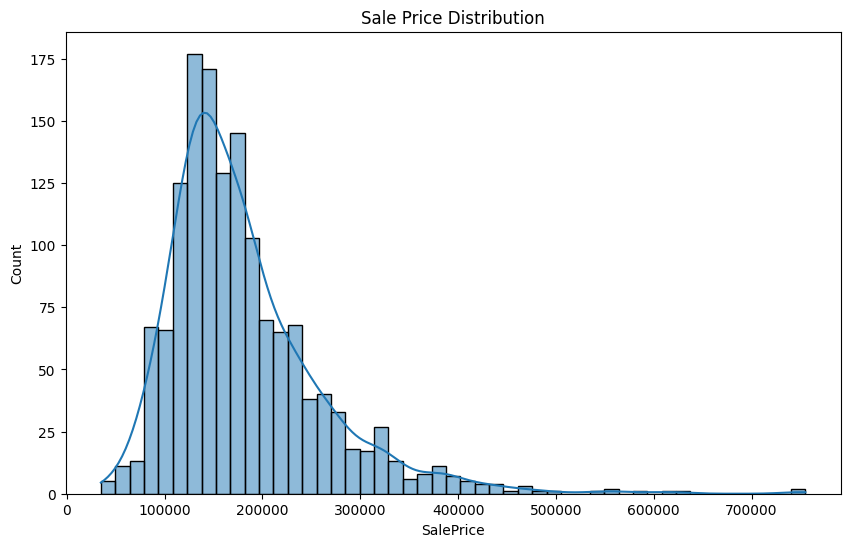

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["SalePrice"],
    kde=True
)

plt.title("Sale Price Distribution")

plt.show()

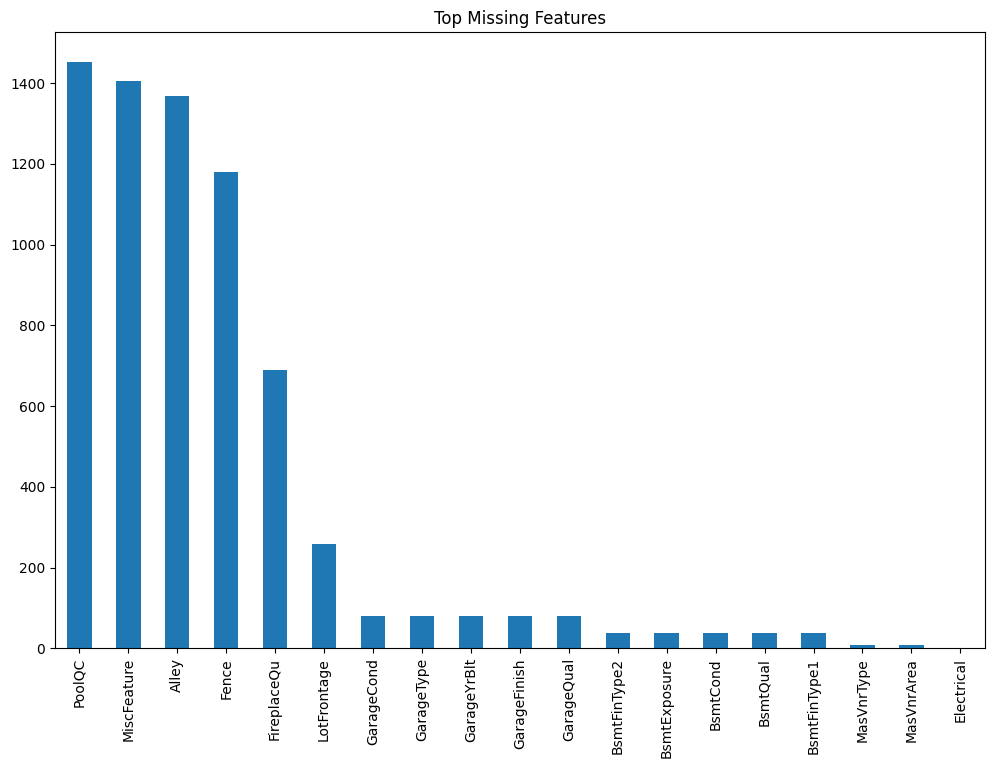

In [32]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing = missing.sort_values(
    ascending=False
)

plt.figure(figsize=(12,8))

missing.head(20).plot(kind="bar")

plt.title("Top Missing Features")

plt.show()

In [33]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

top_corr = corr["SalePrice"] \
    .sort_values(
        ascending=False
    )

print(top_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [34]:
current_year = 2025

df["HouseAge"] = (
    current_year
    - df["YearBuilt"]
)

In [35]:
df["TotalBathrooms"] = (
    df["FullBath"]
    +
    0.5 * df["HalfBath"]
)

In [36]:
df["TotalSF"] = (
    df["TotalBsmtSF"]
    +
    df["1stFlrSF"]
    +
    df["2ndFlrSF"]
)

In [37]:
features = [
    "GrLivArea",
    "GarageCars",
    "TotRmsAbvGrd",
    "YearBuilt"
]

X = df[features]
y = df["SalePrice"]

In [38]:
num_features = X.select_dtypes(
    include=np.number
).columns

cat_features = X.select_dtypes(
    exclude=np.number
).columns

In [39]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [40]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            num_features
        ),
        (
            "cat",
            categorical_transformer,
            cat_features
        )
    ]
)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            random_state=42
        )
}

In [44]:
results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipe.fit(
        X_train,
        y_train
    )

    preds = pipe.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        preds
    )

    results.append(
        [name, r2]
    )

    print(
        f"{name}: {r2:.4f}"
    )

Linear Regression: 0.7064
Random Forest: 0.8363
Gradient Boosting: 0.8378
XGBoost: 0.8306


In [45]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2 Score"
    ]
)

results_df.sort_values(
    "R2 Score",
    ascending=False
)

,Model,R2 Score
2,Gradient Boosting,0.837758
1,Random Forest,0.836285
3,XGBoost,0.830635
0,Linear Regression,0.706449


In [46]:
xgb_pipeline = Pipeline(
    [
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                random_state=42
            )
        )
    ]
)

In [47]:
params = {

    "model__n_estimators":
        [100,200,300],

    "model__max_depth":
        [3,5,7],

    "model__learning_rate":
        [0.01,0.05,0.1]
}

In [48]:
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

search.fit(
    X_train,
    y_train
)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               Index(['GrLivArea', 'GarageCars', 'TotRmsAbvGrd', 'YearBuilt'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handl...
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=None,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300]},
                   scoring='r2')

In [49]:

search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=params,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               Index(['GrLivArea', 'GarageCars', 'TotRmsAbvGrd', 'YearBuilt'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handl...
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=None,
                                                           max_leaves=None,
                                                           min_child_weight=None,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300]},
                   scoring='r2', verbose=1)

In [50]:
best_model = search.best_estimator_

preds = best_model.predict(
    X_test
)

print(
    "R2:",
    r2_score(
        y_test,
        preds
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        preds
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )
)

R2: 0.8454302549362183
MAE: 24386.951171875
RMSE: 34432.54832277158


In [51]:
joblib.dump(
    best_model,
    "best_model.pkl"
)

['best_model.pkl']

In [52]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(
    sample
)

print(
    "Predicted Price:",
    prediction[0]
)

Predicted Price: 135019.44


In [53]:
for i in range(5):
    sample = X_test.iloc[[i]]
    pred = best_model.predict(sample)

    print("Actual:", y_test.iloc[i])
    print("Predicted:", pred[0])
    print("-----")

Actual: 154500
Predicted: 135019.44
-----
Actual: 325000
Predicted: 306668.22
-----
Actual: 115000
Predicted: 114730.914
-----
Actual: 159000
Predicted: 163005.4
-----
Actual: 315500
Predicted: 260800.83
-----


In [38]:
import sklearn
print(sklearn.__version__)

1.6.1
